# Logistic Regression Model Comparisons - Lab

## Introduction

In this lab, you'll investigate using scikit-learn with regularization in order to produce better models.

## Objectives

- Compare the different inputs with logistic regression models and determine the optimal model 

In [1]:
# Import the necessary packages
# Import necessary packages
import pandas as pd              # For data handling
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For visualization
import seaborn as sns            # For statistical data visualization

# Machine Learning Packages
from sklearn.model_selection import train_test_split  # Splitting dataset
from sklearn.preprocessing import StandardScaler      # Feature scaling
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
from sklearn.model_selection import GridSearchCV     # Hyperparameter tuning


## Import the data

Import the dataset stored in `'heart.csv'`.

In [2]:
# Import the data

df = pd.read_csv("heart.csv")

# Print the first five rows of the data
print(df.head())

        age  sex        cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.708333  1.0  1.000000  0.481132  0.244292  1.0      0.0  0.603053    0.0   
1  0.166667  1.0  0.666667  0.339623  0.283105  0.0      0.5  0.885496    0.0   
2  0.250000  0.0  0.333333  0.339623  0.178082  0.0      0.0  0.770992    0.0   
3  0.562500  1.0  0.333333  0.245283  0.251142  0.0      0.5  0.816794    0.0   
4  0.583333  0.0  0.000000  0.245283  0.520548  0.0      0.5  0.702290    1.0   

    oldpeak  slope   ca      thal  target  
0  0.370968    0.0  0.0  0.333333     1.0  
1  0.564516    0.0  0.0  0.666667     1.0  
2  0.225806    1.0  0.0  0.666667     1.0  
3  0.129032    1.0  0.0  0.666667     1.0  
4  0.096774    1.0  0.0  0.666667     1.0  


## Split the data

Define `X` and `y` where the latter is the `target` variable. This time, follow best practices and also implement a standard train-test split. Assign 25% to the test set and set the `random_state` to 17. 

In [3]:
# Define X and y
y = df["target"]  # Target variable
X = df.drop(columns=["target"])  # Features

# Split the data into training and test sets


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=17)
print(y_train.value_counts(),'\n\n', y_test.value_counts())

target
1.0    130
0.0     97
Name: count, dtype: int64 

 target
0.0    41
1.0    35
Name: count, dtype: int64


## Initial Model - scikit-learn

Use scikit-learn to build the logistic regression model.

Turn off the intercept and set the regularization parameter, `C`, to a ridiculously large number such as 1e16. 

In [4]:
# Your code here
# Initialize the logistic regression model
log_reg = LogisticRegression(fit_intercept=False, C=1e16, max_iter=1000, solver='liblinear')

# Train the model
log_reg.fit(X_train, y_train)

# Print model coefficients
print("Model Coefficients:", log_reg.coef_)
print("Model Intercept (should be zero):", log_reg.intercept_)


Model Coefficients: [[ 0.77784048 -2.17889622  2.60276554 -2.64319383 -2.40927977  0.02622115
   1.35660894  6.73431833 -1.10158059 -3.92221991  0.71328729 -3.38839625
  -1.78116783]]
Model Intercept (should be zero): 0.0


## Create an ROC Curve for the scikit-learn model

Use both the training and test sets.

Train AUC: 0.9291038858049168
Test AUC: 0.8996515679442508


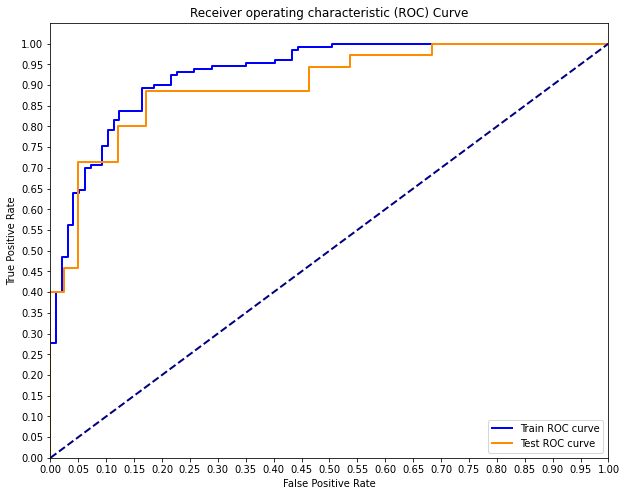

In [6]:
# Your code here
from sklearn.metrics import roc_curve, auc
y_train_score = log_reg.predict_proba(X_train)[:, 1]
y_test_score = log_reg.predict_proba(X_test)[:, 1]

train_fpr, train_tpr, train_thresholds = roc_curve(y_train, y_train_score)
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, y_test_score)


print('Train AUC: {}'.format(auc(train_fpr, train_tpr)))
print('Test AUC: {}'.format(auc(test_fpr, test_tpr)))

plt.figure(figsize=(10, 8))
lw = 2

plt.plot(train_fpr, train_tpr, color='blue',
         lw=lw, label='Train ROC curve')
plt.plot(test_fpr, test_tpr, color='darkorange',
         lw=lw, label='Test ROC curve')

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.yticks([i/20.0 for i in range(21)])
plt.xticks([i/20.0 for i in range(21)])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## Add an Intercept

Now add an intercept to the scikit-learn model. Keep the regularization parameter `C` set to a very large number such as 1e16. 

In [9]:
# Create new model
logregi = LogisticRegression(fit_intercept=True, C=1e16, max_iter=1000, solver='liblinear')


Generate predictions for the training and test sets.

In [11]:
# Ensure the model is trained 
logregi.fit(X_train, y_train)

# Generate predictions
y_hat_train = logregi.predict(X_train)
y_hat_test = logregi.predict(X_test)

Plot all three models ROC curves on the same graph.

Custom Model Test AUC: 0.8331010452961672
Custome Model Train AUC: 0.8429817605075336
Scikit-learn Model 1 Test AUC: 0.8996515679442508
Scikit-learn Model 1 Train AUC: 0.9291038858049168
Scikit-learn Model 2 with intercept Test AUC: 0.8996515679442508
Scikit-learn Model 2 with intercept Train AUC: 0.9291038858049168


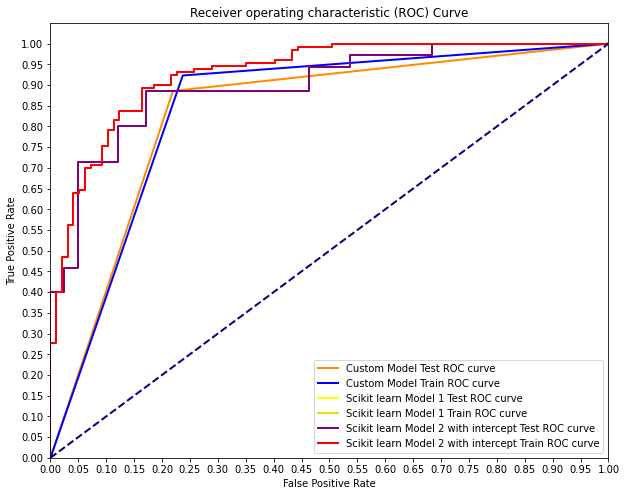

In [15]:
# Initial model plots
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, y_hat_test)
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, y_hat_train)


print('Custom Model Test AUC: {}'.format(auc(test_fpr, test_tpr)))
print('Custome Model Train AUC: {}'.format(auc(train_fpr, train_tpr)))

plt.figure(figsize=(10,8))
lw = 2

plt.plot(test_fpr, test_tpr, color='darkorange',
         lw=lw, label='Custom Model Test ROC curve')
plt.plot(train_fpr, train_tpr, color='blue',
         lw=lw, label='Custom Model Train ROC curve')


# Second model plots
y_test_score = log_reg.decision_function(X_test)
y_train_score = log_reg.decision_function(X_train)

test_fpr, test_tpr, test_thresholds = roc_curve(y_test, y_test_score)
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, y_train_score)

print('Scikit-learn Model 1 Test AUC: {}'.format(auc(test_fpr, test_tpr)))
print('Scikit-learn Model 1 Train AUC: {}'.format(auc(train_fpr, train_tpr)))


plt.plot(test_fpr, test_tpr, color='yellow',
         lw=lw, label='Scikit learn Model 1 Test ROC curve')
plt.plot(train_fpr, train_tpr, color='gold',
         lw=lw, label='Scikit learn Model 1 Train ROC curve')


# Third model plots
y_test_score = log_reg.decision_function(X_test)
y_train_score = log_reg.decision_function(X_train)

test_fpr, test_tpr, test_thresholds = roc_curve(y_test, y_test_score)
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, y_train_score)

print('Scikit-learn Model 2 with intercept Test AUC: {}'.format(auc(test_fpr, test_tpr)))
print('Scikit-learn Model 2 with intercept Train AUC: {}'.format(auc(train_fpr, train_tpr)))


plt.plot(test_fpr, test_tpr, color='purple',
         lw=lw, label='Scikit learn Model 2 with intercept Test ROC curve')
plt.plot(train_fpr, train_tpr, color='red',
         lw=lw, label='Scikit learn Model 2 with intercept Train ROC curve')

# Formatting
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.yticks([i/20.0 for i in range(21)])
plt.xticks([i/20.0 for i in range(21)])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Altering the Regularization Parameter

Now, experiment with altering the regularization parameter. At a minimum, create 5 different subplots with varying regularization (`C`) parameters. For each, plot the ROC curve of the training and test set for that specific model.  

Regularization parameters between 1 and 20 are recommended. Observe the difference in test and training AUC as you go along.

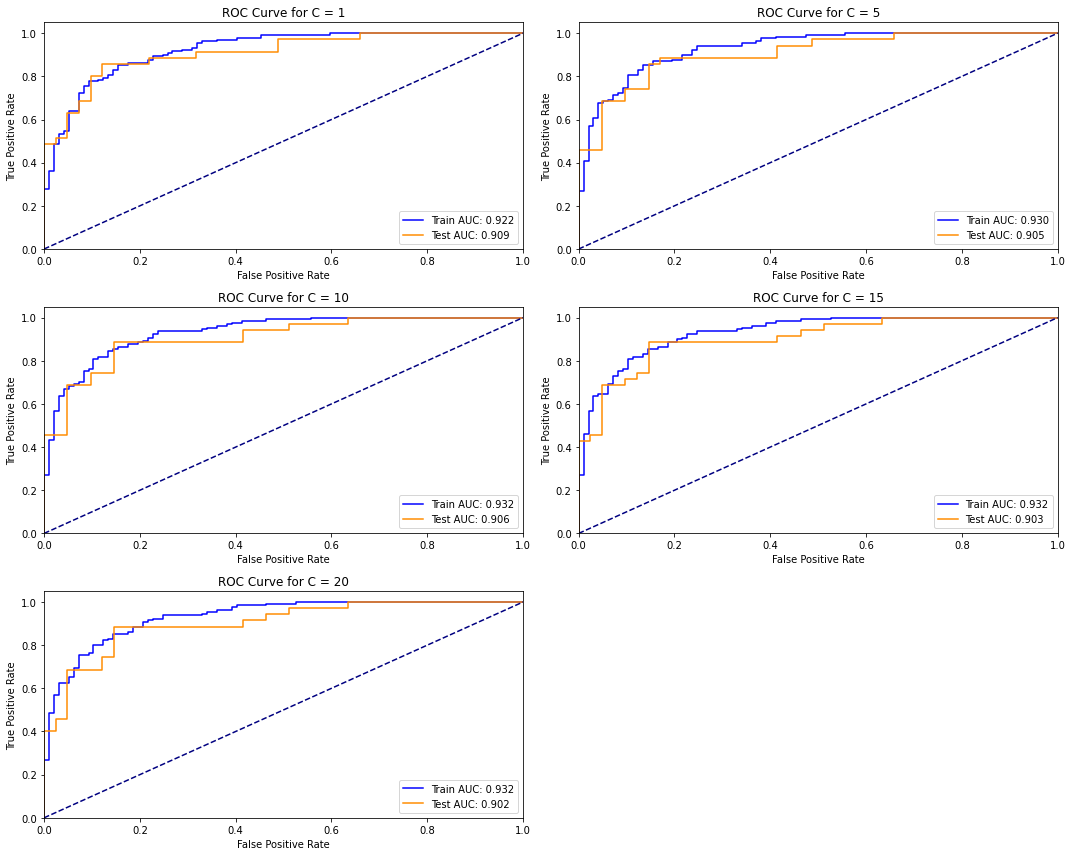

In [16]:
# Your code here
# Regularization parameters to test
C_values = [1, 5, 10, 15, 20]

# Initialize plot
plt.figure(figsize=(15, 12))

# Loop through different values of C and train logistic regression models
for i, C in enumerate(C_values, 1):
    # Train model with specific regularization parameter
    log_reg_var = LogisticRegression(fit_intercept=True, C=C, max_iter=1000, solver='liblinear')
    log_reg_var.fit(X_train, y_train)

    # Compute ROC curve
    y_train_score = log_reg_var.decision_function(X_train)
    y_test_score = log_reg_var.decision_function(X_test)
    
    train_fpr, train_tpr, _ = roc_curve(y_train, y_train_score)
    test_fpr, test_tpr, _ = roc_curve(y_test, y_test_score)

    # Compute AUC scores
    train_auc = auc(train_fpr, train_tpr)
    test_auc = auc(test_fpr, test_tpr)

    # Subplot for each C value
    plt.subplot(3, 2, i)
    plt.plot(train_fpr, train_tpr, color='blue', label=f'Train AUC: {train_auc:.3f}')
    plt.plot(test_fpr, test_tpr, color='darkorange', label=f'Test AUC: {test_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for C = {C}')
    plt.legend(loc="lower right")

# Adjust layout and show plots
plt.tight_layout()
plt.show()


How did the regularization parameter impact the ROC curves plotted above? 

**Impact of Regularization Parameter (C) on the ROC Curves**

The regularization parameter (C) controls the strength of L2 regularization (inverse of penalty strength) in logistic regression.

**Key Observations from the ROC Curves:**

**For small C values (e.g., C = 1, 5):**

The model is more constrained, meaning it applies stronger regularization.

The training and test ROC curves are close to each other, indicating less overfitting.

However, the test AUC is slightly lower, meaning the model may be underfitting.

**For larger C values (e.g., C = 10, 15, 20):**

The model is less constrained, allowing it to fit the training data better.

The training AUC increases, showing that the model is capturing more complexity.

However, the gap between training and test AUC increases, suggesting potential overfitting (the model learns noise from training data but doesn't generalize well).

**General Trend:**

Stronger regularization (low C) → Simpler model, lower AUC, less overfitting.

Weaker regularization (high C) → More flexible model, higher AUC, risk of overfitting.

**The optimal C value** balances bias (underfitting) and variance (overfitting) to achieve the best generalization.



## Summary

In this lab, you reviewed many of the accuracy measures for classification algorithms and observed the impact of additional tuning models using intercepts and regularization.